# 逻辑回归(Logistic Regression)原理与PyTorch实战详解
## 一、逻辑回归核心原理
### 1.1 模型本质与定位
逻辑回归虽名为“回归”，但本质是**监督学习二分类算法**，核心是通过特征线性组合+非线性映射，输出样本属于正类的概率（0~1区间），再通过阈值判定类别。
- 与线性回归的核心区别：线性回归输出连续值（预测数值），逻辑回归输出概率值（预测类别）。
- 核心应用场景：风控建模、垃圾邮件识别、用户转化预测、医疗诊断等二分类任务。

### 1.2 数学公式推导
#### 1.2.1 线性部分（Affine Model）
先对输入特征做线性加权组合，公式对应图片中 $\hat{y} = x * \omega + b$：
$$z = \omega^T x + b$$
- $x$：输入特征向量（维度为 $n$）；
- $\omega$：权重参数（与特征维度一致）；
- $b$：偏置项（截距）；
- $z$：线性输出，值域为 $(-\infty, +\infty)$。

#### 1.2.2 Sigmoid映射（核心激活函数）
将线性输出 $z$ 映射到0~1概率区间，公式对应图片中 $\hat{y} = \sigma(x * \omega + b)$，Sigmoid函数定义：
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
**函数特性**：
- 值域：$z \to +\infty$ 时，$\sigma(z) \to 1$；$z \to -\infty$ 时，$\sigma(z) \to 0$；$z=0$ 时，$\sigma(z)=0.5$；
- 单调性：单调递增，可直观反映概率变化趋势；
- 可导性：导数公式简洁，便于梯度优化，$\sigma'(z) = \sigma(z)(1-\sigma(z))$。

#### 1.2.3 概率与分类决策
逻辑回归输出 $\hat{y} = \sigma(z)$ 表示样本属于**正类（标签1）**的概率，负类（标签0）概率为 $1-\hat{y}$。
**决策规则**：设定阈值（默认0.5），
- 若 $\hat{y} \geq 0.5$，预测为正类（1）；
- 若 $\hat{y} < 0.5$，预测为负类（0）。

### 1.3 损失函数与优化
#### 1.3.1 损失函数选择：交叉熵损失
分类任务不适用均方误差（MSE），MSE会导致损失函数非凸、梯度消失，而**交叉熵损失（Cross-Entropy Loss）**是凸函数，能保证梯度下降找到全局最优解，且源于极大似然估计。
**二元交叉熵损失公式**：
$$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^m \left[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \right]$$
- $m$：样本数量；
- $y_i$：真实标签（0或1）；
- $\hat{y}_i$：模型预测概率。

#### 1.3.2 优化算法：梯度下降
通过梯度下降最小化损失函数，更新参数 $\omega$ 和 $b$：
1. 计算损失对参数的梯度；
2. 按学习率 $\eta$ 更新参数：
$$\omega = \omega - \eta \cdot \frac{\partial \mathcal{L}}{\partial \omega}$$
$$b = b - \eta \cdot \frac{\partial \mathcal{L}}{\partial b}$$
PyTorch中可直接调用`Optimizer`（如SGD、Adam）自动完成梯度计算与参数更新。

## 二、PyTorch实现逻辑回归
### 2.1 代码实现





In [3]:
import torch
import torch.nn.functional as F
x_data = torch.Tensor([[1.0], [2.0], [3.0]])
y_data = torch.Tensor([[0], [0], [1]])

class LogisticRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)

    def forward(self, x):
        y_pred = F.sigmoid(self.linear(x))
        return y_pred

model = LogisticRegressionModel()
criterion = torch.nn.BCELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(1000):
    # 前向传播
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    # 更新参数
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.4f}")


Epoch 0: loss=4.2734
Epoch 100: loss=2.0511
Epoch 200: loss=1.8625
Epoch 300: loss=1.7051
Epoch 400: loss=1.5725
Epoch 500: loss=1.4601
Epoch 600: loss=1.3640
Epoch 700: loss=1.2811
Epoch 800: loss=1.2090
Epoch 900: loss=1.1458


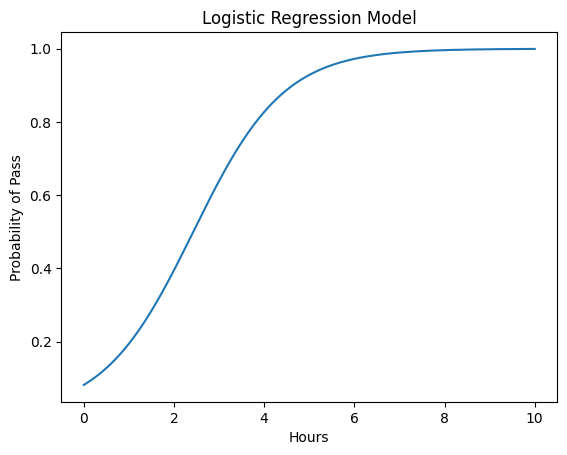

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)          # 生成0到10之间的200个均匀分布的数
x_t = torch.Tensor(x).view(200, 1)   # 转换为PyTorch张量并调整形状
y_t = model(x_t)                     # 模型预测
y = y_t.data.numpy()                 # 预测结果转回NumPy数组

plt.plot(x, y)
plt.xlabel("Hours")
plt.ylabel("Probability of Pass")
plt.title("Logistic Regression Model")
plt.show()



### 2.1 导入依赖库
```python
import torch
import torch.nn.functional as F
```
- `torch`：PyTorch核心库，提供张量运算、神经网络构建、自动求导等基础功能；
- `torch.nn.functional`：简称`F`，包含各类神经网络的激活函数、损失函数等功能函数（如这里用到的`sigmoid`）。

### 2.2 定义数据集
```python
x_data = torch.Tensor([[1.0], [2.0], [3.0]])
y_data = torch.Tensor([[0], [0], [1]])
```
- `x_data`：输入特征张量，形状为`(3, 1)`，表示3个样本，每个样本只有1个特征（单变量）；
- `y_data`：标签张量，形状为`(3, 1)`，对应3个样本的二分类标签（0/1），需与模型输出形状一致。

### 2.3 定义逻辑回归模型
```python
class LogisticRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)

    def forward(self, x):
        y_pred = F.sigmoid(self.linear(x))
        return y_pred
```
#### 核心说明：
1. **模型继承规则**：
   - 所有PyTorch自定义模型必须继承`torch.nn.Module`，这是PyTorch神经网络的基类，提供参数管理、前向传播、设备迁移等核心功能；
   - `super().__init__()`：调用父类构造函数，初始化模型基础属性。

2. **线性层定义**：
   - `self.linear = torch.nn.Linear(1, 1)`：定义线性变换层，参数`(in_features=1, out_features=1)`，对应公式 $z = \omega x + b$：
     - `in_features=1`：输入特征维度（每个样本1个特征）；
     - `out_features=1`：输出维度（线性层原始输出，未经过激活）；
     - 该层自动初始化权重$\omega$和偏置$b$两个可训练参数。

3. **前向传播逻辑**：
   - `forward`方法是PyTorch模型的核心，定义数据的前向计算流程；
   - `self.linear(x)`：对输入`x`做线性变换，得到$z = \omega x + b$；
   - `F.sigmoid(...)`：将线性输出`z`通过Sigmoid函数映射到`[0,1]`区间，得到预测概率 $y_{pred} = \sigma(z) = \frac{1}{1+e^{-z}}$，这是逻辑回归的核心非线性变换。

### 2.4 初始化模型、损失函数、优化器
```python
model = LogisticRegressionModel()
criterion = torch.nn.BCELoss(size_average=False)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
```
#### 关键解析：
1. **模型实例化**：`model = LogisticRegressionModel()` 创建模型对象，此时线性层的$\omega$和$b$会被初始化为随机值。

2. **损失函数（BCELoss）**：
   - `torch.nn.BCELoss`：二元交叉熵损失（Binary Cross Entropy Loss），专门用于二分类任务，公式为：
     $$\mathcal{L} = -\sum_{i=1}^n [y_i \log(y_{pred,i}) + (1-y_i) \log(1-y_{pred,i})]$$
   - `size_average=False`：表示损失计算时**不做均值归一化**，直接返回所有样本的损失之和（若设为`True`则返回均值）；
     > 注意：新版PyTorch中`size_average`已被`reduction`替代（`reduction='sum'`等价于`size_average=False`，`reduction='mean'`等价于`size_average=True`）。

3. **优化器（SGD）**：
   - `torch.optim.SGD`：随机梯度下降优化器，用于更新模型参数；
   - `model.parameters()`：获取模型中所有可训练参数（即线性层的$\omega$和$b$）；
   - `lr=0.01`：学习率（Learning Rate），控制参数更新的步长，是梯度下降的核心超参数。

### 2.5 模型训练循环
```python
for epoch in range(1000):
    # 前向传播
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    # 更新参数
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.4f}")
```
#### 训练流程拆解（核心三步）：
1. **前向传播（Forward）**：
   - `y_pred = model(x_data)`：将输入数据传入模型，得到所有样本的预测概率；
   - `loss = criterion(y_pred, y_data)`：计算预测值与真实标签的交叉熵损失，量化模型预测误差。

2. **反向传播（Backward）**：
   - `optimizer.zero_grad()`：清空所有参数的梯度缓存（PyTorch梯度会累加，若不清空会导致梯度错误）；
   - `loss.backward()`：自动求导，计算损失对每个可训练参数（$\omega$、$b$）的梯度，即 $\frac{\partial \mathcal{L}}{\partial \omega}$ 和 $\frac{\partial \mathcal{L}}{\partial b}$。

3. **参数更新（Update）**：
   - `optimizer.step()`：根据计算出的梯度，按SGD规则更新参数：
     $$\omega = \omega - lr \cdot \frac{\partial \mathcal{L}}{\partial \omega}$$
     $$b = b - lr \cdot \frac{\partial \mathcal{L}}{\partial b}$$

4. **日志打印**：
   - `epoch % 100 == 0`：每100轮打印一次损失值，监控训练过程；
   - `loss.item()`：提取张量形式的损失值为Python数值（避免张量计算的额外开销）。

